# Week 8 - Data Cleaning, Feature Engineering, and Splitting the Dataset
You will explore the Ames housing data set this week.   You will look at cleaning the data, splitting it into two sets (training and testing), fixing missing data, and creating pipelines.   You will learn a new machine learning library called scikit-learn. 

- Import the pandas library with pd as a shortcut.
- Read in the Ames housing data from a file named "AmesHousing_1.csv".  Store it in a variable called ames_df.
- display the first 5 records of the data.
- In a new code cell, display the column names using the info method.


In [1]:
import pandas as pd
ames_df =  pd.read_csv("AmesHousing_1.csv")
ames_df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
ames_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

# Display the percentages of values
To display the percentage of each value in columns, use the following command.
```
df['column'].value_counts(normalize = True) * 100
```

In [3]:
ames_df['Roof Matl'].value_counts(normalize = True) * 100

Roof Matl
CompShg    98.532423
Tar&Grv     0.784983
WdShake     0.307167
WdShngl     0.238908
Membran     0.034130
ClyTile     0.034130
Roll        0.034130
Metal       0.034130
Name: proportion, dtype: float64

In [4]:
ames_df['MS SubClass'].value_counts(normalize = True) * 100

MS SubClass
20     36.825939
60     19.624573
50      9.795222
120     6.552901
30      4.744027
160     4.402730
70      4.368601
80      4.027304
90      3.720137
190     2.081911
85      1.638225
75      0.784983
45      0.614334
180     0.580205
40      0.204778
150     0.034130
Name: proportion, dtype: float64

# Drop Column with duplicate data
Sometimes the data contains columns that provide duplicate information.  When that occurs, we can drop the column.  Your data set also had some additional columns but they were dropped since I asked you to complete that task.  To drop a column or columns you can use code as following.
```
CL = ["column1", "column2"...]
df.drop(columns = CL, axis = 1, inplace = True)
```
In your assignment you will be asked to drop columns that contains record values that offer no information for

In [5]:
# Drop column with duplicate data
DD = ["MS SubClass"]
ames_df.drop(columns = DD, axis = 1, inplace = True)
ames_df.columns

Index(['MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape',
       'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood',
       'Condition 1', 'Condition 2', 'Bldg Type', 'House Style',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
       'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars',
     

# Determine Outliers in the Dataset
Extreme values in the data will not be useful in predicting the data that fall into the average data range.  In those cases, we can delete data that falls into this category.

Where living SF is greater than 4000 sq feet we will eliminate the records.  Theses living spaces are not representative of the average home owner.
```
rec_no = df[df['column'] > value].index
df.drop(rec_no, axis = 0, inplace = True)
```


In [6]:
ot = ames_df[ames_df['Gr Liv Area'] > 4000].index
ames_df.drop(ot, axis = 0, inplace = True)

# Determining the distribution of the variable
When trying to predict a continuous variable, there is an assumption of normality for the variable.  What does that mean?  It means that the distribution of the data is bell-shaped(symmetric).  We need to see if that is the case.  We can use a distribution function or a histogram to test this assumption.

- Import the seaborn library with a shortcut so
- Import the matplotlib.pyplot with the shortcut plt.
- Create fig, ax from the plt subplots
- Use ax to set the title as "Sales Price Distribution"
- Use the seaborn shortcut to create a density plot using the SalesPrice column no hue and fill True


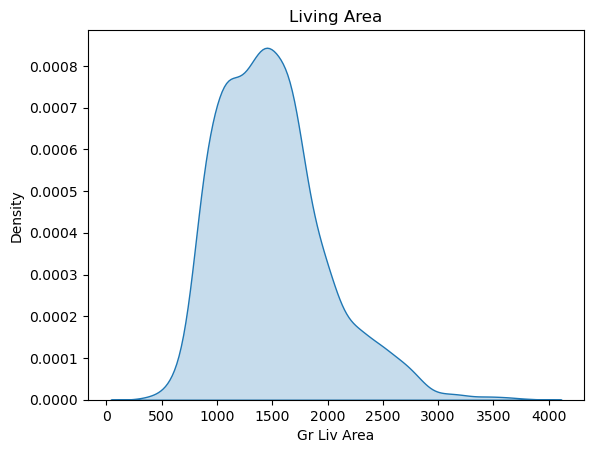

In [7]:
import seaborn as so
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.set(title = "Living Area")
so.kdeplot(data = ames_df, x = "Gr Liv Area", fill = True);

# Create a histogram of Living Area
Another way to test the assumption is to create a histogram of the 
- use pandas plot method to create a histogram that is g(green), the edgecolor c(cyan), and title "Sales Price Distribution".  Set bins to 25.
- Enter the parameters in this order kind, color, edgecolor, title, and bins.  Use the parameter and = to set the parameters


<Axes: title={'center': 'Gr Living Area Distribution'}, ylabel='Frequency'>

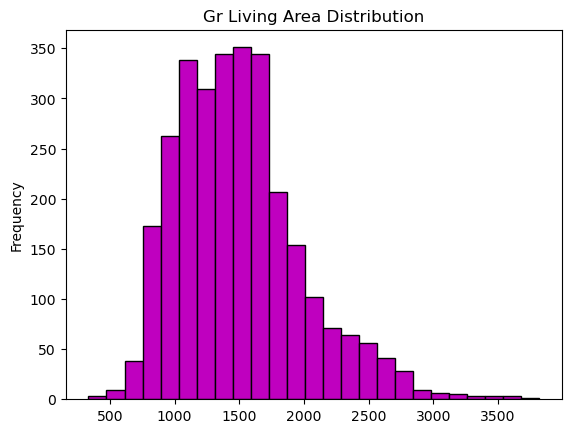

In [8]:
ames_df['Gr Liv Area'].plot(kind = 'hist', color = 'm', edgecolor = 'k', title = 'Gr Living Area Distribution', bins = 25)

# Shape of the distribution
- if there a lot of small values on right we say it is right skewed
- if there a lot of small values on the left we say it left skewed
- if it is symmetric we say it bell-shaped.

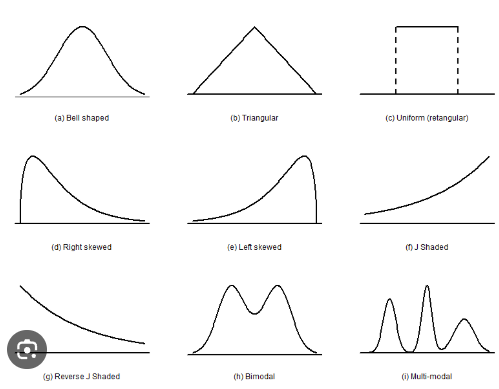

# Fixing our column values to be more normal
You can apply a log to the column to make the distribution more normal than it was before.
```
df['column'] = np.log(df['column'])
df['column'].plot(kind = 'hist', color = 'm', edgecolor = 'k', title = 'Log Distribution', bins = 25)
```

<Axes: title={'center': 'Log Distribution'}, ylabel='Frequency'>

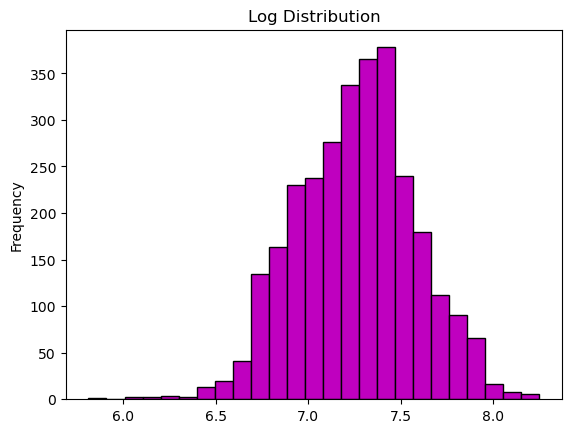

In [9]:
import numpy as np
ames_df['Log_GrLivArea'] = np.log(ames_df['Gr Liv Area'])
ames_df['Log_GrLivArea'].plot(kind = 'hist', color = 'm', edgecolor = 'k', title = 'Log Distribution', bins = 25)

# Some variables that have missing value implies None
In some of the columns that have missing values and the missing values should be replaced with 'None'. This is the case with the following columns.

```
LX = ['column1', 'column2', ...]
for i in LX:
    df[i] = df[i].fillna('None")
```

Create a list with the following columns 'Pool QC', 'Garage Finish' in a variable named BN.
Create a for loop with index x to cycle through the list, BN changing missing value to 'None'.

In [10]:
ames_df['Pool QC'] = ames_df['Pool QC'].fillna('None')
ames_df.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Log_GrLivArea
0,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,None,NaN,NaN,0,5,2010,WD,Normal,215000,7.412160
1,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,None,MnPrv,NaN,0,6,2010,WD,Normal,105000,6.797940
2,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,None,NaN,Gar2,12500,6,2010,WD,Normal,172000,7.192182
3,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,...,None,NaN,NaN,0,4,2010,WD,Normal,244000,7.654443
4,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,...,None,MnPrv,NaN,0,3,2010,WD,Normal,189900,7.395722


In [11]:
BN = ['Pool QC', 'Garage Finish']
for i in BN:
    ames_df[i] = ames_df[i].fillna('None') 

# Change missing values for numeric value that imply 0
Some columns will have missing values and they imply 0.  In this case, we will change the missing values to 0.
```
L0 = ['column1', 'column2',..]
for y in L0:
    df[y] = df[y].fillna(0)
```
The following columns missing value implies 0.

- Create a List 'Wood Deck SF', 'Garage Cars', 'Garage Area' store it in a variable called JK
- JK = ['Wood Deck SF', 'Garage Cars', 'Garage Area']
- Create a for loop with index y cycle through JK and set missing values to 0
- for y in JK:<br>
    ames_df[y] = ames_df[y].fillna(0)

In [12]:
JK = ['Wood Deck SF', 'Garage Cars', 'Garage Area']
for y in JK:
    ames_df[y] = ames_df[y].fillna(0)

# Changing Ordinal Categorical data into numbers
Some categorical data has order, therefore, number values other than 0 and 1 are appropriate.  When this happens, we can map the category to a value and change the category to numeric numbers.
```
# Display the values in 'Exter Qual'.
df['column'].value_counts(normalize = True) * 100
# Create a dictionary called new_values
new_values = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
# Map the labels to new values and replace missing value with 3 since it the most common value.
df['column'] = ames['column'].map(new_values).fillna(3)
```

In [13]:
ames_df['Kitchen Qual'].value_counts(normalize = True) * 100

Kitchen Qual
TA    51.076923
Gd    39.658120
Ex     6.837607
Fa     2.393162
Po     0.034188
Name: proportion, dtype: float64

In [14]:

new_values = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
ames_df['Kitchen Qual'] = ames_df['Kitchen Qual'].map(new_values).fillna(3)

In [15]:
ames_df['Kitchen Qual'].value_counts(normalize = True) * 100

Kitchen Qual
3    51.076923
4    39.658120
5     6.837607
2     2.393162
1     0.034188
Name: proportion, dtype: float64

# Creating a New column from Existing Data
Sometimes you can combine columns to create new variables that are meaningful to the model.  After you create the new variable, be sure to delete the columns you used to create the new variable.
```
# Multiply 'Overall Qual' and 'Gr Liv Area' and store the result in a column named 'Quality_Area'.
df['newcolumn'] = df['column1'] * df['column2'] + df['column3]
```
- Multiply 'Overall Qual' and 'Gr Liv Area' and store the result in a column named 'Quality_Area'.
- Add the 'Overall Qual' and the 'Overall Cond' and store it in a column called 'Total_Rating'


In [16]:
ames_df['Quality_Area'] = ames_df['Overall Qual'] * ames_df['Gr Liv Area']
ames_df['Total_Rating'] = ames_df['Overall Qual'] + ames_df['Overall Cond']

# Dividing the dataset into train and test
```
from sklearn.model_selection import train_test_split
#Create bins from the 'Gr Liv Area' column and save a new column called GrLiv_cut.
df['column2'] = pd.cut(df['column1'], bins = 5, labels = [1, 2, 3, 4, 5])
# Split the data into train and test data sets
train, test = train_test_split(ames_df, test_size = 0.30, random_state = 42, stratify = ames_df['column2'])
#Drop the column created in both the train and test data set
train.drop('column2', axis = 1, inplace = True)
test.drop('column2', axis = 1, inplace = True)
```

In [17]:
# Create bins from the 'Gr Liv Area' column and save a new column called GrLiv_cut.
from sklearn.model_selection import train_test_split
ames_df['GrLiv_cat'] = pd.cut(ames_df['Gr Liv Area'], bins = 5, labels = [1, 2, 3, 4, 5])
train, test = train_test_split(ames_df, test_size = 0.30, random_state = 42, stratify = ames_df['GrLiv_cat'])
train.drop('GrLiv_cat', axis = 1, inplace = True)
test.drop('GrLiv_cat', axis = 1, inplace = True)

In [18]:
len(train)

2047

In [19]:
len(test)

878

In [20]:
train.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Log_GrLivArea,Quality_Area,Total_Rating
1790,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,8,2007,WD,Normal,307000,7.434848,13552,13
1741,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,6,2007,New,Partial,172500,7.137278,8806,12
1836,FV,32.0,3784,Pave,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,NaN,0,2,2007,New,Partial,193800,7.355641,12520,13
1665,RL,63.0,9457,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,9,2007,WD,Normal,155000,7.259820,7110,11
738,RM,50.0,6000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,1,2009,WD,Normal,119000,6.806829,5424,13


In [21]:
test.head()

,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Log_GrLivArea,Quality_Area,Total_Rating
1129,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,4,2008,New,Partial,230348,7.104965,8526,12
1041,RM,21.0,1890,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,4,2008,WD,Normal,100500,6.894670,5922,12
402,RM,21.0,1680,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,NaN,0,7,2009,WD,Normal,111000,6.894670,5922,11
2239,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,...,NaN,0,11,2007,WD,Abnorml,67000,6.981935,5385,7
2072,RL,NaN,11075,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,...,NaN,0,2,2007,WD,Normal,182000,7.327781,9132,11
